In [ ]:
!pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def build_rnn():
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=(max_len, 1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def build_lstm():
    model = Sequential()
    model.add(LSTM(64, input_shape=(max_len, 1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def build_gru():
    model = Sequential()
    model.add(GRU(64, input_shape=(max_len, 1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

In [ ]:
results = {}

def train_model(name, build_fn):
    print(f"\nTraining {name}...")

    model = build_fn()

    start = time.time()
    history = model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.2, verbose=1)
    end = time.time()

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results[name] = {
        "accuracy": acc,
        "loss": loss,
        "time": end - start
    }

    return history

In [ ]:
rnn_hist = train_model("RNN", build_rnn)
lstm_hist = train_model("LSTM", build_lstm)
gru_hist = train_model("GRU", build_gru)


Training RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.5134 - loss: 0.6959 - val_accuracy: 0.5014 - val_loss: 0.6995
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5048 - loss: 0.6950 - val_accuracy: 0.5084 - val_loss: 0.6943
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5128 - loss: 0.6937 - val_accuracy: 0.4954 - val_loss: 0.6953

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5209 - loss: 0.6938 - val_accuracy: 0.5534 - val_loss: 0.6875
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5353 - loss: 0.6885 - val_accuracy: 0.5356 - val_loss: 0.6889
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5477 - loss: 0.6871 - val_accuracy: 0.5396 - val_loss: 0.6883

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5157 - loss: 0.6960 - val_accuracy: 0.5348 - val_loss: 0.6891
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.531

In [ ]:
for model in results:
    print(f"{model}: Accuracy={results[model]['accuracy']:.4f}, Loss={results[model]['loss']:.4f}, Time={results[model]['time']:.2f}s")

RNN: Accuracy=0.5068, Loss=0.6944, Time=17.74s
LSTM: Accuracy=0.5256, Loss=0.6914, Time=13.60s
GRU: Accuracy=0.5592, Loss=0.6836, Time=12.78s


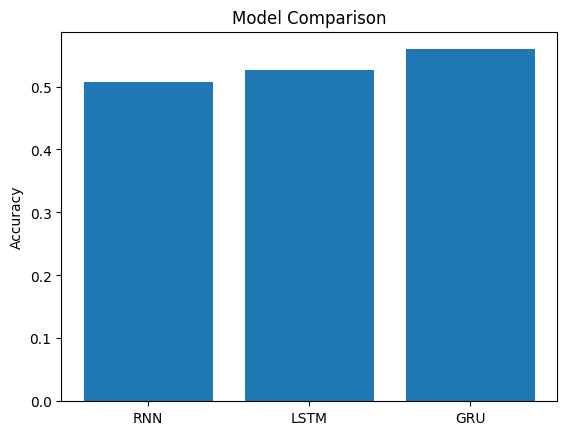

In [ ]:
models = list(results.keys())
accuracies = [results[m]["accuracy"] for m in models]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()